In [1]:
import pandas as pd

# Load the dataset from your Data folder
df = pd.read_csv('Data/Telco-Customer-Churn.csv')

# Display the first 5 rows to ensure it loaded correctly
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 1. Check the data types and look for missing values
print("--- DATA INFO ---")
df.info()

print("\n--- CHURN COUNT ---")
# 2. See exactly how many customers left (Yes) vs stayed (No)
df['Churn'].value_counts()

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [3]:
# 1. Convert TotalCharges to numeric, forcing errors (blank spaces) to turn into NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check how many blank values we just exposed
print("Missing values found:", df['TotalCharges'].isnull().sum())

# 3. Drop those few missing rows (it's safe since there are very few)
df.dropna(inplace=True)

# 4. Confirm the fix and the new row count
print("Total rows after cleaning:", len(df))

Missing values found: 11
Total rows after cleaning: 7032


In [4]:
pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

# Fix the data type issue for TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 1. Clean target and IDs
df_clean = df.drop('customerID', axis=1)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Features
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
                        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                        'Contract', 'PaperlessBilling', 'PaymentMethod']

# 4. Preprocessing Engines
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 5. Master Pipeline
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])

# 6. Hyperparameter Tuning
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# 7. Train & Save
print("Tuning Pipeline... This might take a minute!")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
joblib.dump(best_pipeline, 'churn_pipeline.pkl')
print("✅ Production-grade pipeline saved successfully! You can now update app.py.")

Tuning Pipeline... This might take a minute!


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

✅ Production-grade pipeline saved successfully! You can now update app.py.


In [6]:
import joblib
joblib.dump(best_pipeline, 'churn_pipeline.pkl')
print("Fresh pipeline exported!")

Fresh pipeline exported!


In [7]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, classification_report

# Use best_pipeline to evaluate the tuned model
y_prob = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC  : 0.83
Precision: 0.59
Recall   : 0.588

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



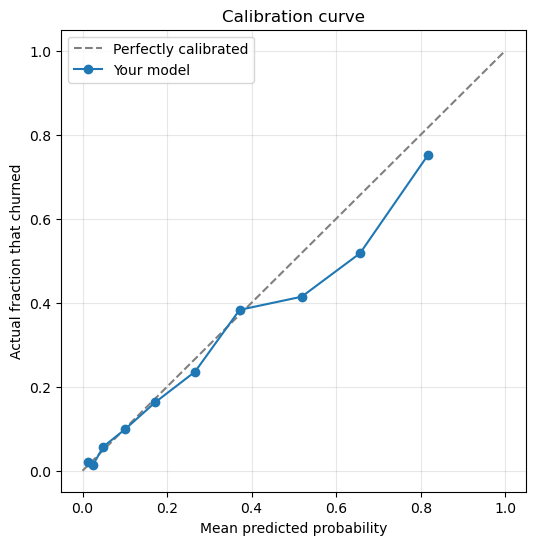

Brier score (lower is better, 0 = perfect): 0.1442
   Predicted probability  Actual churn rate  Gap (predicted - actual)
0                  0.012              0.021                    -0.009
1                  0.025              0.014                     0.011
2                  0.049              0.057                    -0.008
3                  0.101              0.099                     0.002
4                  0.172              0.163                     0.009
5                  0.266              0.236                     0.030
6                  0.372              0.383                    -0.011
7                  0.518              0.414                     0.104
8                  0.656              0.518                     0.139
9                  0.817              0.752                     0.066


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Use the same test set and pipeline as before
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# y_test must be 0/1 — convert if it's still "Yes"/"No"
y_true = y_test.map({"Yes": 1, "No": 0}) if y_test.dtype == object else y_test

# Bucket predictions into 10 bins and compare predicted vs actual churn rate
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.plot(prob_pred, prob_true, marker="o", label="Your model")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual fraction that churned")
plt.title("Calibration curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Brier score (lower is better, 0 = perfect):", round(brier_score_loss(y_true, y_prob), 4))

# Table view, easier to read exact numbers
calib_table = pd.DataFrame({
    "Predicted probability": prob_pred,
    "Actual churn rate": prob_true,
    "Gap (predicted - actual)": prob_pred - prob_true,
})
print(calib_table.round(3))